# MINI PROJECT Final

### please restart kernel if re-running cells 

## Imports

In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import os
import copy


## Helper Functions

### Easy / Medium

In [2]:
def plot_images_from_sets(image_sets, images_per_row=4, max_images=15):
    '''
    flexible multi-image plotter for single figure viewing
    '''

    if isinstance(image_sets, list) and all(isinstance(i, list) for i in image_sets):
        pass
    else:
        image_sets = [image_sets]
        
    for image_set in image_sets:
        for i in range(0, min(len(image_set), max_images), images_per_row):
            plt.figure(figsize=(30, 16))
            for j in range(images_per_row):
                if i + j < min(len(image_set), max_images):
                    plt.subplot(1, images_per_row, j + 1)
                    plt.imshow(image_set[i + j], cmap='gray')
                    plt.axis('off')
            plt.show()
            plt.close()


def harris_corner_detection(image_list, threshold, color):
    '''
    detects corner points in the easy/medium image(s) using the Harris corner detection algorithm
    '''

    images = []
    harriskp_sets = []

    for image in image_list:

        #params for harris corner detection
        block_size = 2     
        ksize = 3            
        k = 0.04             

        dst = cv2.cornerHarris(image, block_size, ksize, k)
        harris_points = np.argwhere(dst > threshold * dst.max())  # Thresholding
        harris_points = [tuple(pt[::-1]) for pt in harris_points]  # Convert to (x, y)
        harriskp_sets.append(harris_points)


        dst = cv2.dilate(dst, None)  
        color_image = cv2.cvtColor(image, cv2.COLOR_GRAY2BGR)
        color_image[dst > threshold * dst.max()] = color

        #point drawing
        for point in harris_points:
            cv2.circle(color_image, point, 3, color, -1)

        images.append(color_image)  

    return images, harriskp_sets


def filter_lines(image, length_threshold, width_threshold):
    '''
    filters the lines in the image using the length and width thresholds fo contour bounding boxes
    '''

    image_color = cv2.cvtColor(image, cv2.COLOR_GRAY2BGR)

    #finding the contours in input image
    contours, _ = cv2.findContours(image, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    filtered = np.zeros_like(image_color)
    line_coords = []

    
    #filtering contours by bounding box length and width
    for contour in contours:
        x, y, w, h = cv2.boundingRect(contour)

        if cv2.arcLength(contour, True) > length_threshold and w < width_threshold:
            
            if w < width_threshold:
                if w > h:  # Horizontal line
                    cv2.line(filtered, (0, y + h // 2), (filtered.shape[1], y + h // 2), (255, 255, 255), 2)
                    line_coords.append(((0, y + h // 2), (filtered.shape[1], y + h // 2)))

                else:  # Vertical line
                    cv2.line(filtered, (x + w // 2, 0), (x + w // 2, filtered.shape[0]), (255, 255, 255), 2)
                    line_coords.append(((x + w // 2, 0), (x + w // 2, filtered.shape[0])))
    
    #sorting line coordinates by x-coordinate
    line_coords = sorted(line_coords, key=lambda x: x[0][0])
    
    #removing line too close to each other in the x plane
    line_coords = [line_coords[0]] + [
        line for j, line in enumerate(line_coords[1:], 1) 
        if line[0][0] - line_coords[j - 1][1][0] > 20
    ]

    
    return filtered, line_coords


def completing_boxes(image,merge_img ,num_lines):
    '''
    adding the top and bottom lines to parking space detections using harris points
    '''    
    img = copy.deepcopy(image)

    pixels = np.array(img)

    #finding harris points in image
    red_points = np.where((pixels[:, :, 0] > 200) & (pixels[:, :, 1] < 50) & (pixels[:, :, 2] < 50))
    red_y_coords = red_points[0]  # Y-coordinates of red points

    #quantizing the y-coordinates of the red points
    hist, bin_edges = np.histogram(red_y_coords, bins=60)
    top_regions = np.argsort(hist)[-num_lines:]  # Indices of the highest bins
    top_regions_centers = [(bin_edges[i] + bin_edges[i+1]) / 2 for i in top_regions]

    #drawing the top and bottom lines using the num lines
    for center in top_regions_centers:
        cv2.line(merge_img, (0, int(center)), (img.shape[1], int(center)), (0, 255, 0), 2)

    return merge_img


def find_parking_spaces_easy(image, ar, at=2000):
    '''
    finding parking spaces using contours of a certain aspect ratio and area
    '''

    img = copy.deepcopy(image)

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    edges = cv2.Canny(gray, 50, 150)
    contours, _ = cv2.findContours(edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    desired_aspect_ratio = ar
    parking_spaces = []

    area_sorted = sorted(contours, key=cv2.contourArea, reverse=True)
    area_mean = np.mean([cv2.contourArea(contour) for contour in area_sorted])
    area_sorted = [contour for contour in area_sorted if cv2.contourArea(contour) > (area_mean + at)]

    for contour in area_sorted:
        epsilon = 0.04 * cv2.arcLength(contour, True)
        approx = cv2.approxPolyDP(contour, epsilon, True)

        if len(approx) == 4:
            x, y, w, h = cv2.boundingRect(approx)
            aspect_ratio = w / h

            if abs(aspect_ratio - desired_aspect_ratio) < 0.15:
                cv2.drawContours(img, [approx], 0, (255, 255, 0), 2)
                parking_spaces.append((x, y, w, h))

    return img, parking_spaces


def find_parking_spaces_medium(image, ar, at = 100000000, e=True):
    '''
    finding parking spaces using contours of a certain aspect ratio and area for medium sets
    '''

    img = copy.deepcopy(image)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    edges = cv2.Canny(gray, 50, 150)
    contours, _ = cv2.findContours(edges, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
    desired_aspect_ratio = ar
    parking_spaces = []

    area_threshold = at

    area_sorted = sorted(contours, key=cv2.contourArea, reverse=True)
    
    areas = [cv2.contourArea(contour) for contour in area_sorted if cv2.contourArea(contour) > 3000]
    area_median = np.median(areas)
    area_sorted2 = [contour for contour in area_sorted if cv2.contourArea(contour) < (area_median + area_threshold)]

    for contour in area_sorted2:
        if e:
            x, y, w, h = cv2.boundingRect(contour)

            # Calculate the aspect ratio
            aspect_ratio = w / h

            if abs(aspect_ratio - desired_aspect_ratio) < 0.2:  # Allow small tolerance
                #print the contour if the left side is touching the left side of the image
                cv2.drawContours(img, [contour], 0, (255, 255, 0), 2)  # Draw the rectangle
                parking_spaces.append((x, y, w, h))
        else:
            x, y, w, h = cv2.boundingRect(contour)

            # Calculate the aspect ratio
            aspect_ratio = w / h

            if abs(aspect_ratio - desired_aspect_ratio) < 0.1:  # Allow small tolerance
                #print the contour if the left side is touching the left side of the image
                cv2.drawContours(img, [contour], 0, (255, 255, 0), 2)  # Draw the rectangle
                parking_spaces.append((x, y, w, h))
                
    return img, parking_spaces


def fix_camera_distortion(image):
    '''
    fixing the camera distortion in the second image of the medium set
    '''

    test = copy.deepcopy(image)

    pts_src = np.float32([[0, 20], [875, 50], [20, 190], [890, 200]])

    # Define points in the desired output image (e.g., a perfect rectangle)
    pts_dst = np.float32([[0, 20], [885, 15], [20, 190], [890, 200]])

    # Compute the perspective transform matrix
    matrix = cv2.getPerspectiveTransform(pts_src, pts_dst)
    inv_matrix1 = cv2.getPerspectiveTransform(pts_dst, pts_src)

    # Apply the perspective transformation
    result = cv2.warpPerspective(test, matrix, (890, 204))

    pts_src_2 = np.float32([[0, 0], [855, 10], [20, 190], [890, 195]])
    pts_dst_2 = np.float32([[0, 0], [890, 0], [0, 200], [880, 195]])

    matrix_2 = cv2.getPerspectiveTransform(pts_src_2, pts_dst_2)
    inv_matrix2 = cv2.getPerspectiveTransform(pts_dst_2, pts_src_2)
    result_2 = cv2.warpPerspective(result, matrix_2, (890, 204))

    return result_2,inv_matrix1,inv_matrix2

### Hard

In [3]:

def rotate_h1(image, angle):
    '''
    roatating the first image of the hard to achieve straight lines
    '''

    rows, cols = image.shape[:2]
    rotation_matrix = cv2.getRotationMatrix2D((cols / 2, rows / 2), angle, 1)
    rotated_image = cv2.warpAffine(image, rotation_matrix, (cols, rows))

    return rotated_image


def rotate_h3(image):
    '''
    rotating the third hard image to achieve straight lines
    '''

    rows, cols = image.shape[:2]
    angle = 2.5
    rotation_matrix = cv2.getRotationMatrix2D((cols / 2, rows / 2), angle, 1)
    rotated_image = cv2.warpAffine(image, rotation_matrix, (cols, rows))

    return rotated_image


def blue_and_white_colour_masking(image):
    '''
    colour masking to remove blue and white lines for the second image from the hard set using the hsv color space
    '''
    hsv = cv2.cvtColor(image, cv2.COLOR_RGB2HSV)

    lower_blue = np.array([100, 50, 50])
    upper_blue = np.array([140, 255, 255])

    mask = cv2.inRange(hsv, lower_blue, upper_blue)
    result1 = cv2.bitwise_and(image, image, mask=mask)


    lower_white = np.array([0, 0, 200])
    upper_white = np.array([255, 255, 255])

    mask = cv2.inRange(image, lower_white, upper_white)
    result2 = cv2.bitwise_and(image, image, mask=mask)

    #bledning masks 
    final = cv2.bitwise_or(result1, result2)

    return final


def filter_lines_h1(image, length_threshold, width_threshold, gap_threshold=True):
    '''
    filtering the lines in the first hard image using length,width,proximity to other lines
    '''

    contours, _ = cv2.findContours(image, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    line_coords = []

    for contour in contours:

        x, y, w, h = cv2.boundingRect(contour)

        # If the contour length is above the threshold
        if cv2.arcLength(contour, True) > length_threshold and w < width_threshold:
            if w > h:  # Horizontal line
                line_coords.append(((0, y + h // 2), (image.shape[1], y + h // 2)))
            else:  # Vertical line
                line_coords.append(((x + w // 2, 0), (x + w // 2, image.shape[0])))


    # Filter lines based on proximity
    if gap_threshold:
        if len(line_coords) > 1:
            line_coords = [line_coords[0]] + [
                line for j, line in enumerate(line_coords[1:], 1) 
                if line[0][0] - line_coords[j - 1][1][0] > 35
            ]

    # Create an empty image to draw on
    filtered = np.zeros_like(cv2.cvtColor(image, cv2.COLOR_GRAY2BGR))

    # Draw the filtered lines
    for start, end in line_coords:
        cv2.line(filtered, start, end, (255, 255, 255), 2)

    return filtered, line_coords


def filter_lines_h2(image, length_threshold, width_threshold, gap_threshold=False):
    '''
    filtering the lines in the second hard image using length,width,proximity to other lines
    '''

    contours, _ = cv2.findContours(image, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    line_coords = []


    for contour in contours:
        x, y, w, h = cv2.boundingRect(contour)

        if cv2.arcLength(contour, True) > length_threshold and w < width_threshold:
            if w > h:  
                line_coords.append(((0, y + h // 2), (image.shape[1], y + h // 2)))
            else:  
                line_coords.append(((x + w // 2, 0), (x + w // 2, image.shape[0])))


    line_coords.sort(key=lambda x: x[0][0])

    # Filter lines based on proximity
    if gap_threshold:
        if len(line_coords) > 1:
            line_coords = [line_coords[0]] + [
                line for j, line in enumerate(line_coords[1:], 1) 
                if line[0][0] - line_coords[j - 1][1][0] > 35
            ]


    #draw the filtered lines
    filtered = np.zeros_like(cv2.cvtColor(image, cv2.COLOR_GRAY2BGR))

    for start, end in line_coords:
        cv2.line(filtered, start, end, (255, 255, 255), 2)

    return filtered, line_coords


def filter_lines_h3(image, length_threshold, width_threshold, gap_threshold=False):

    '''
    similar approach to filtering lines for other hard images, with slight changes to the gap threshold and other bits and pieces

    '''

    contours, _ = cv2.findContours(image, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    line_coords = []


    for contour in contours:

        x, y, w, h = cv2.boundingRect(contour)

        if cv2.arcLength(contour, True) > length_threshold and w < width_threshold:
            if w > h: 
                line_coords.append(((0, y + h // 2), (image.shape[1], y + h // 2)))
            else:  
                line_coords.append(((x + w // 2, 0), (x + w // 2, image.shape[0])))


    line_coords.sort(key=lambda x: x[0][0])

    if gap_threshold:
        if len(line_coords) > 1:
            line_coords = [line_coords[0]] + [
                line for j, line in enumerate(line_coords[1:], 1) 
                if line[0][0] - line_coords[j - 1][1][0] > 100
            ]


    filtered = np.zeros_like(cv2.cvtColor(image, cv2.COLOR_GRAY2BGR))

    for start, end in line_coords:
        cv2.line(filtered, start, end, (255, 255, 255), 2)



    return filtered, line_coords


def completing_boxes_h1(image,merge_img ,num_lines):
    '''
    completing the top and bottom lines of the parking spaces, simpler approach than other images
    '''
    
    img = image.copy()

    pixels = np.array(img)

    red_points = np.where((pixels[:, :, 0] > 200) & (pixels[:, :, 1] < 50) & (pixels[:, :, 2] < 50))
    red_y_coords = red_points[0]  # Y-coordinates of red points

    hist, bin_edges = np.histogram(red_y_coords, bins=60)
    top_regions = np.argsort(hist)[-num_lines:]  # Indices of the highest bins
    top_regions_centers = [(bin_edges[i] + bin_edges[i+1]) / 2 for i in top_regions]

    for center in top_regions_centers:
        cv2.line(merge_img, (0, int(center)), (img.shape[1], int(center)), (0, 255, 0), 2)

    return merge_img


def completing_boxes_h2(image, merge_img, num_lines):
    '''
    completing the top and bottom lines of the parking spaces, using dynamic line y-coordinate detection 
    '''

    
    img = copy.deepcopy(image)
    pixels = np.array(img)

    # Identify red points in image
    red_points = np.where((pixels[:, :, 0] > 200) & (pixels[:, :, 1] < 50) & (pixels[:, :, 2] < 50))
    red_y_coords = red_points[0]

    # Create a histogram of red y-coordinates
    hist, bin_edges = np.histogram(red_y_coords, bins=50)  
    sorted_bins = np.argsort(hist)[::-1]  #Sort bins by count in descending order

    filtered_centers = []
    i = 0

    # Select centers dynamically, ensuring spacing of at least 300 pixels
    # i.e if the distance between two bins is less than desired, we find the next highest bin
    while len(filtered_centers) < num_lines and i < len(sorted_bins):
        center = (bin_edges[sorted_bins[i]] + bin_edges[sorted_bins[i] + 1]) / 2
        if all(abs(center - existing) > 200 for existing in filtered_centers):
            filtered_centers.append(center)
        i += 1


    # If we cannot find enough lines with spacing constraints, relax the threshold
    if len(filtered_centers) < num_lines:
        for j in range(len(sorted_bins)):
            if len(filtered_centers) >= num_lines:
                break
            center = (bin_edges[sorted_bins[j]] + bin_edges[sorted_bins[j] + 1]) / 2
            if center not in filtered_centers:  # Allow closer centers as a fallback
                filtered_centers.append(center)


    # Draw lines on the merge_img
    for center in filtered_centers:
        cv2.line(merge_img, (0, int(center)), (img.shape[1], int(center)), (0, 255, 0), 2)


    return merge_img


def completing_boxes_h3(image, merge_img, num_lines):

    '''
    parking space top and bottom line drawing for the final hard image
    similar approach to previous image with slight changes in the spacing constraints/relaxation of constraints
    '''

    img = copy.deepcopy(image)
    pixels = np.array(img)

    red_points = np.where((pixels[:, :, 0] > 200) & (pixels[:, :, 1] < 50) & (pixels[:, :, 2] < 50))
    red_y_coords = red_points[0]

    hist, bin_edges = np.histogram(red_y_coords, bins=50)  
    sorted_bins = np.argsort(hist)[::-1]  

    filtered_centers = []
    i = 0

    while len(filtered_centers) < num_lines and i < len(sorted_bins):
        center = (bin_edges[sorted_bins[i]] + bin_edges[sorted_bins[i] + 1]) / 2
        if all(abs(center - existing) > 300 for existing in filtered_centers):
            filtered_centers.append(center)
        i += 1

    if len(filtered_centers) < num_lines:
        for j in range(len(sorted_bins)):
            if len(filtered_centers) >= num_lines:
                break
            center = (bin_edges[sorted_bins[j]] + bin_edges[sorted_bins[j] + 1]) / 2
            if center not in filtered_centers:  
                filtered_centers.append(center)

    for center in filtered_centers:
        cv2.line(merge_img, (0, int(center)), (img.shape[1], int(center)), (0, 255, 0), 2)

    return merge_img


def harris_corner_detection_hard(image, threshold, color):

    '''
    harris corner detection for hard image set
    '''
    images = []
    harriskp_sets = []


    block_size = 2     
    ksize = 3            
    k = 0.04             

    dst = cv2.cornerHarris(image, block_size, ksize, k)
    harris_points = np.argwhere(dst > threshold * dst.max())
    harris_points = [tuple(pt[::-1]) for pt in harris_points]  
    harriskp_sets.append(harris_points)

    dst = cv2.dilate(dst, None)  

    color_image = cv2.cvtColor(image, cv2.COLOR_GRAY2BGR)

    color_image[dst > threshold * dst.max()] = color

    for point in harris_points:
        cv2.circle(color_image, point, 3, color, -1)

         
    return color_image, harriskp_sets


def find_parking_spaces_h1(image, ar, at = 2000):

    '''
    find the parking spaces in hard image 0 using a similar approach to the medium difficulty images
    mean area thresholding and aspect ratio filtering of contours and bounding boxes of contours
    '''
    img = image.copy()
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    edges = cv2.Canny(gray, 50, 150)
    contours, _ = cv2.findContours(edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    desired_aspect_ratio = ar
    parking_spaces = []

    area_threshold = at

    area_sorted = sorted(contours, key=cv2.contourArea, reverse=True)
        
        #remove all contours with area threshold greater than the mean area
    area_mean = np.mean([cv2.contourArea(contour) for contour in area_sorted])
    area_sorted = [contour for contour in area_sorted if cv2.contourArea(contour) > (area_mean + area_threshold)]

    for contour in area_sorted:

        epsilon = 0.04 * cv2.arcLength(contour, True)
        approx = cv2.approxPolyDP(contour, epsilon, True)

        # Check if the shape has 4 sides (potential rectangle)
        if len(approx) == 4:
            # Get the bounding rectangle
            x, y, w, h = cv2.boundingRect(approx)

            # Calculate the aspect ratio
            aspect_ratio = w / h

            # If aspect ratio is within a desired range, draw the rectangle
            if abs(aspect_ratio - desired_aspect_ratio) < 0.2:  # Allow small tolerance
                    cv2.drawContours(img, [approx], 0, (255, 255, 0), 2)  # Draw the rectangle
                    parking_spaces.append((x, y, w, h))


    return img, parking_spaces


def find_parking_spaces_h2(image, dw, at=100000000, e=True, max_height = 220):

    '''
    finding parking spaces by filtering contours based on area and and specific height and width
    takes into account contour hierarchy (must be the parent contour)
    clips the bbox height if it exceeds max_height
    '''

    img = copy.deepcopy(image)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    edges = cv2.Canny(gray, 50, 150)

    # Get contours and hierarchy
    contours, hierarchy = cv2.findContours(edges, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
    hierarchy = hierarchy[0]

    parking_spaces = []
    area_threshold = at


    # Filter out contours based on median area to avoid outliers with correct other variables
    area_sorted = sorted(contours, key=cv2.contourArea, reverse=True)
    areas = [cv2.contourArea(contour) for contour in area_sorted if 100000 < cv2.contourArea(contour) < 50000000]
    area_median = np.median(areas)
    area_sorted2 = [contour for contour in area_sorted if cv2.contourArea(contour) < (area_median + area_threshold)]


    # Process contours, skipping inner ones based on hierarchy
    for i, contour in enumerate(area_sorted2):
        x, y, w, h = cv2.boundingRect(contour)

        # Clip the height if it exceeds max_height
        if h > max_height:
            h = max_height  

        #adaptive image processing based on the area of the image after all lines had been detected
        #uses max height param for clipping only in specific areas of the image
        if y < img.shape[0] * 0.15:
            continue
        elif (y > img.shape[0] * 0.15) and (y < img.shape[0] * 0.6):
            if abs(w - dw) < 40 and 100 < h < 999999999999:
                cv2.rectangle(img, (x, y), (x + w, y + h), (255, 255, 0), 2)
                parking_spaces.append((x, y, w, h))
        elif y > img.shape[0] * 0.6:
            if abs(w - dw) < 40 and 200 < h < 250:
                cv2.rectangle(img, (x, y), (x + w, y + h), (255, 255, 0), 2)
                parking_spaces.append((x, y, w, h))

    return img, parking_spaces


def find_parking_spaces_h3(image, dw, at=100000000, e=True):

    '''
    finding parking spaces in hard image 3 using a similar but simpler approach to hard image 2, no max height clipping
    still uses contour hierarchy as well as exact bbox width and height comparisons instead of aspect ratio
    as well as y coordinate based filtering
    
    '''

    #copy / edge dets
    img = copy.deepcopy(image)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    edges = cv2.Canny(gray, 50, 150)


    contours, hierarchy = cv2.findContours(edges, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
    hierarchy = hierarchy[0]

    parking_spaces = []

    area_threshold = at

    #area filtering again
    area_sorted = sorted(contours, key=cv2.contourArea, reverse=True)
    areas = [cv2.contourArea(contour) for contour in area_sorted if cv2.contourArea(contour) > 1000 and cv2.contourArea(contour) < 100000]
    area_median = np.median(areas)
    area_sorted2 = [contour for contour in area_sorted if cv2.contourArea(contour) < (area_median + area_threshold)]


    # skipping inner contours based on hierarchy
    for i, contour in enumerate(area_sorted2):

        # Check if this contour has no parent (outer contour) or it's the largest enclosing contour
        if hierarchy[i][3] == -1:  # -1 means no parent
            x, y, w, h = cv2.boundingRect(contour)

            # Adaptive image processing based on the y coordinate after the lines have been detected
            if y < img.shape[0] * 0.5:
                if abs(w - dw ) < 60 and h > 275 and h < 500:
                    cv2.drawContours(img, [contour], 0, (255, 255, 0), 2)
                    parking_spaces.append((x, y, w, h))
            else:
                if abs(w - dw ) < 60 and h > 400 and h < 500:
                    cv2.drawContours(img, [contour], 0, (255, 255, 0), 2)
                    parking_spaces.append((x, y, w, h))
        
        else:
            # Inner contour: Check if it is part of an outer contour and skip
            parent_idx = hierarchy[i][3]
            parent_contour = contours[parent_idx]
            parent_area = cv2.contourArea(parent_contour)
            current_area = cv2.contourArea(contour)

            # Only consider the parent if it's significantly larger
            if parent_area > 1.5 * current_area:
                continue  

    return img, parking_spaces



## Data Read In

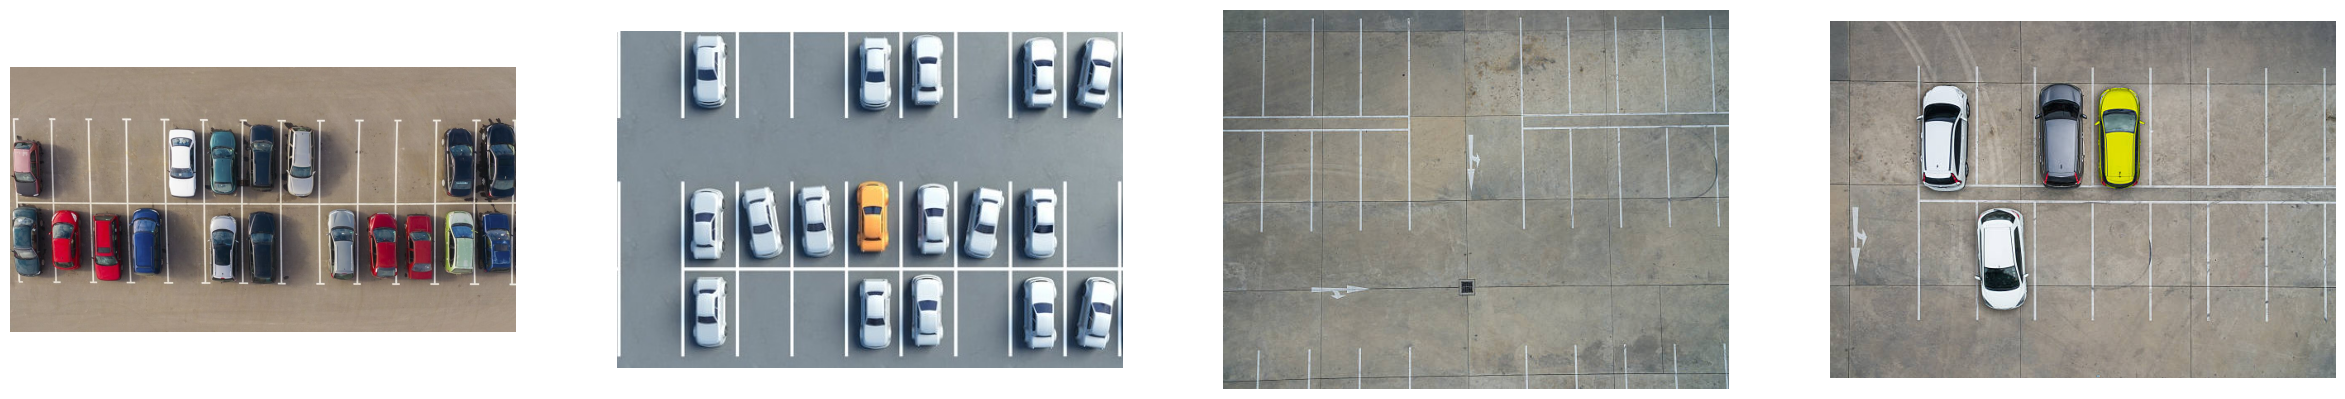

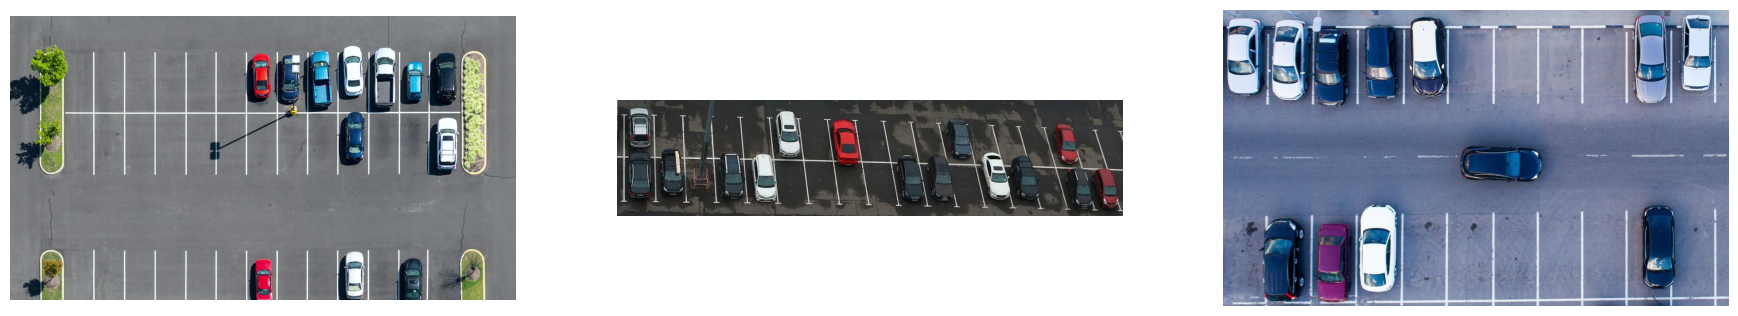

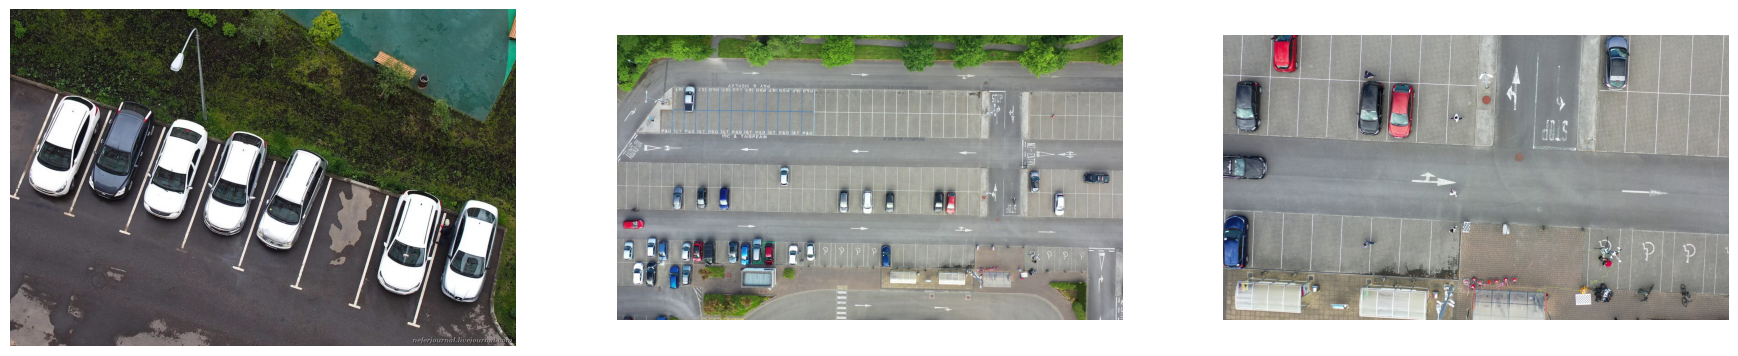

In [4]:
p1 = 'Mini_project_export/Mini_project_images/easy'
p2 = 'Mini_project_export/Mini_project_images/medium'
p3 = 'Mini_project_export/Mini_project_images/hard'

paths = [p1,p2,p3]
images = []

for p in paths:
    files = os.listdir(p)
    for file in files:
        image = cv2.imread(os.path.join(p, file))
        images.append(cv2.cvtColor(image,cv2.COLOR_BGR2RGB))

easy,medium,hard = images[:4],images[4:7],images[7:10]

all_images = [easy,medium,hard]



plot_images_from_sets(all_images)

## Easy

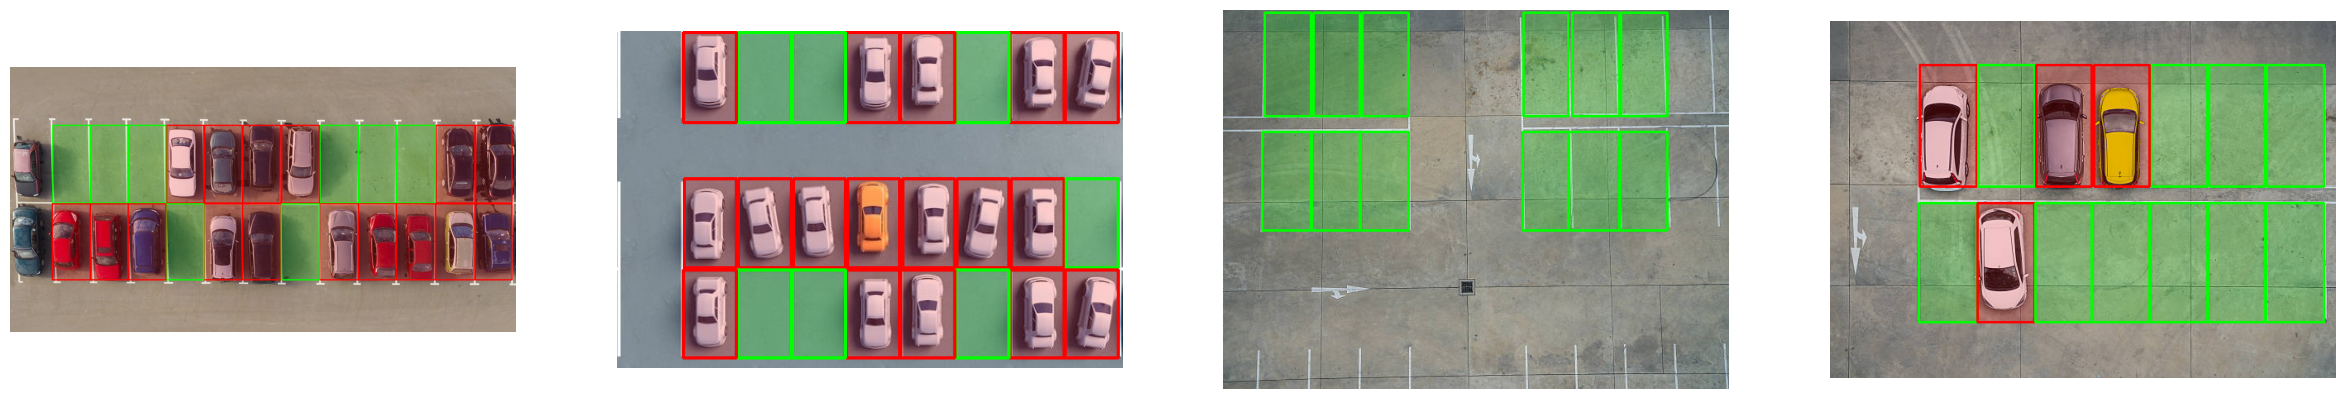

In [5]:
# merging Parameters
α = 0.8
β = 1.0
λ = 0.0

blurred = [cv2.GaussianBlur(img, (3, 3), 10) for img in easy]
# plot_images_from_sets(blurred)


kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (15, 15))
shadow_removed = [cv2.morphologyEx(img, cv2.MORPH_TOPHAT, kernel) for img in blurred]
# plot_images_from_sets(shadow_removed)


gray_shadow_removed = [cv2.cvtColor(img, cv2.COLOR_BGR2GRAY) for img in shadow_removed]
thresholded = [cv2.threshold(img, 0, 255, cv2.THRESH_OTSU)[1] for img in gray_shadow_removed]
# plot_images_from_sets(thresholded)


dkernel = cv2.getStructuringElement(cv2.MORPH_RECT, (1, 10))
dilated = [cv2.dilate(img, dkernel, iterations=1) for img in thresholded]
# plot_images_from_sets(dilated)


harris_images, harris_points = harris_corner_detection(dilated, 0.25, [255, 0, 0])
# plot_images_from_sets(harris_images)


#non-blurred shadow removal
shadow_removed = [cv2.morphologyEx(img, cv2.MORPH_TOPHAT, kernel) for img in easy]
# plot_images_from_sets(shadow_removed)

gray_shadow_removed = [cv2.cvtColor(img, cv2.COLOR_BGR2GRAY) for img in shadow_removed]
binary = [cv2.threshold(img, 50, 255, cv2.THRESH_BINARY)[1] for img in gray_shadow_removed]
# plot_images_from_sets(binary)


vertical_kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (1, 45))
horizontal_kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (55, 1))
vertical_lines_removed = [cv2.morphologyEx(img, cv2.MORPH_OPEN, vertical_kernel) for i,img in enumerate(binary)]
horizontal_lines_removed = [cv2.morphologyEx(img, cv2.MORPH_OPEN, horizontal_kernel) for img in binary]

# Filter Lines Dynamically
filtered_ver, filtered_hor,  = [], []
dkernel = cv2.getStructuringElement(cv2.MORPH_RECT, (1, 10))
dilated = [cv2.dilate(img, dkernel, iterations=1) for i,img in enumerate(vertical_lines_removed)]

for i, img in enumerate(dilated):
    if i == 0:
        filtered, lines = filter_lines(img, length_threshold=350, width_threshold=50)
    elif i == 1:
        filtered, lines = filter_lines(img, length_threshold=175, width_threshold=5)
    elif i == 2:
        filtered, lines = filter_lines(img, length_threshold=175, width_threshold=50)
    else:
        filtered, lines = filter_lines(img, length_threshold=210, width_threshold=4)
    
    filtered_ver.append(filtered)

filtered_hor = [filter_lines(img, length_threshold=300, width_threshold=100000)[0] for img in horizontal_lines_removed]
joined = [cv2.bitwise_or(v, h) for v, h in zip(filtered_ver, filtered_hor)]
copy_joined = [img.copy() for img in joined]
# plot_images_from_sets(joined)


finals, filt_points = [], []
for pt_set, img in zip(harris_points, joined):
    one_set = []
    for point in pt_set:
        if np.all(img[point[1], point[0]] == 255):
            one_set.extend(point)
            cv2.circle(img, point, 6, (255, 0, 0), -1)
    filt_points.append(one_set)
    finals.append(img)
# plot_images_from_sets(finals)



boxes = []
for i, (img, merge) in enumerate(zip(finals, copy_joined)):
    img = completing_boxes(img, merge, 2 if i == 3 else 3)
    boxes.append(img)
# plot_images_from_sets(boxes)



parking_spaces = []
aspect_ratios = [0.6, 0.5, 0.4, 0.55]
for i, ar in enumerate(aspect_ratios):
    boxed_image, spaces = find_parking_spaces_easy(boxes[i], ar)
    parking_spaces.append(spaces)
# plot_images_from_sets(boxes)



merged_imgs = []
for image, box_set in zip(easy, parking_spaces):
    for box in box_set:
        x, y, w, h = box
        cv2.rectangle(image, (x, y), (x + w, y + h), (255, 255, 0), 2)
    merged_imgs.append(image)
# plot_images_from_sets(merged_imgs)




final_easy = [img.copy() for img in easy]
for i, pset in enumerate(parking_spaces):
    if isinstance(pset, list):
        for (x, y, w, h) in pset:
            box = False
            corner_count = 0
            for px, py in harris_points[i]:
                if x + w * 0.25 <= px <= x + w * 0.75 and y + h * 0.25 <= py <= y + h * 0.75:
                    corner_count += 1
                    if (i == 2 and corner_count > 20) or (i != 2 and corner_count > 4):
                        box = True
                        break
            color = (255, 0, 0) if box else (0, 255, 0)
            cv2.rectangle(final_easy[i], (x, y), (x + w, y + h), color, 2)
            overlay = final_easy[i].copy()
            cv2.rectangle(overlay, (x, y), (x + w, y + h), color, -1)
            cv2.addWeighted(overlay, 0.2, final_easy[i], 0.8, 0, final_easy[i])
plot_images_from_sets(final_easy)


## Medium

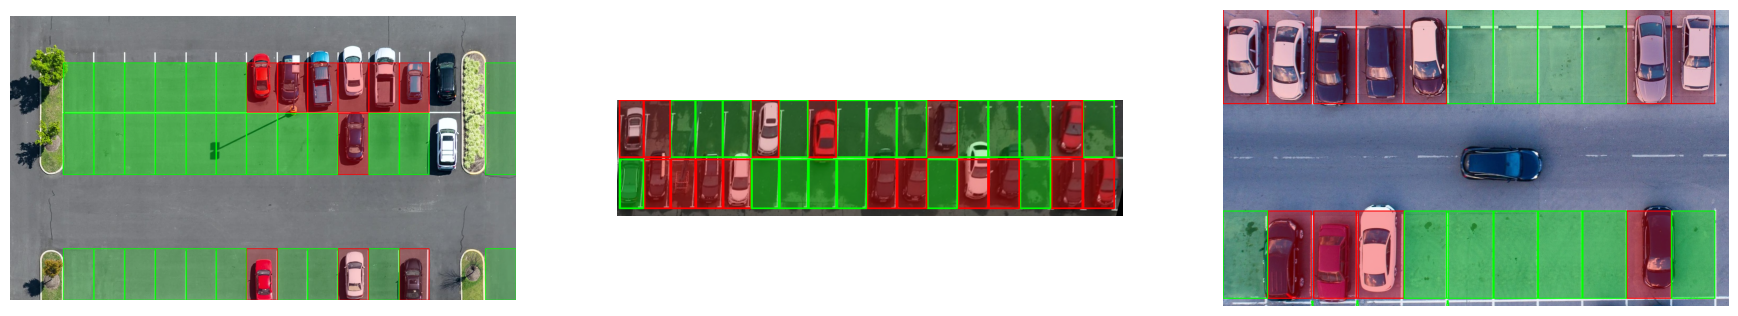

In [6]:

result_2, inv1,inv2 = fix_camera_distortion(medium[1])


medium[1] = result_2




blurred = [cv2.GaussianBlur(img,(5,5),10) for img in medium]
# plot_images_from_sets(blurred)

kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (15, 15))
shadow_removed = [cv2.morphologyEx(gray, cv2.MORPH_TOPHAT, kernel) for gray in blurred]
# plot_images_from_sets(shadow_removed)

gray_shadow_removed = [cv2.cvtColor(img, cv2.COLOR_BGR2GRAY) for img in shadow_removed]
thresholded = [cv2.threshold(img, 0, 255, cv2.THRESH_OTSU)[1] for img in gray_shadow_removed]
# plot_images_from_sets(thresholded)

#dilate the set next
dkernel = cv2.getStructuringElement(cv2.MORPH_RECT, (1, 10))
dilated = [cv2.dilate(img, dkernel, iterations=1) for img in thresholded]
# plot_images_from_sets(dilated)


#harris corner detection
harris_images, harris_points_med = harris_corner_detection(dilated, 0.05, [255, 0, 0])
# plot_images_from_sets(harris_images)




# Define kernels and parameters
common_kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (15, 15))
vertical_kernel_common = cv2.getStructuringElement(cv2.MORPH_RECT, (1, 45))
horizontal_kernel_common = cv2.getStructuringElement(cv2.MORPH_RECT, (55, 1))
dkernel_common = cv2.getStructuringElement(cv2.MORPH_RECT, (1, 10))

# Parameters for dynamic filtering
length_thresholds = [450, 100, 360]  # Thresholds for vertical lines
width_thresholds = [10, 1, 8]

# Initialize results
filtered_ver = []
filtered_hor = []
filt_lines = []
intersections_sets = []
joined_results = []

# Iterate over all images in the set
for i, gray in enumerate(medium):
    # Shadow removal (common step for all images)
    shadow_removed = cv2.morphologyEx(gray if i != 1 else result_2, cv2.MORPH_TOPHAT, common_kernel)

    # Grayscale and binarization
    gray_shadow_removed = cv2.cvtColor(shadow_removed, cv2.COLOR_BGR2GRAY)
    binary = cv2.threshold(gray_shadow_removed, 50, 255, cv2.THRESH_BINARY)[1]

    if i == 1: 
        
        kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (15, 15))
        shadow_removed = cv2.morphologyEx(result_2, cv2.MORPH_TOPHAT, kernel)


        gray_shadow_removed = cv2.cvtColor(shadow_removed, cv2.COLOR_BGR2GRAY)
        binary = cv2.threshold(gray_shadow_removed, 50, 255, cv2.THRESH_BINARY)[1]


        vertical_kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (1, 20))
        horizontal_kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (55, 1))

        vjoin_kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (1, 30))
        hjoin_kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (25, 1))



        vertical_lines_removed = cv2.morphologyEx(binary, cv2.MORPH_OPEN, vertical_kernel)
        horizontal_lines_removed = cv2.morphologyEx(binary, cv2.MORPH_OPEN, horizontal_kernel)


        # Dilation and filtering
        dkernel = cv2.getStructuringElement(cv2.MORPH_RECT, (1, 10))
        dilated = cv2.dilate(vertical_lines_removed, dkernel, iterations=11)
        filtered_ver_img, lines = filter_lines(dilated, length_threshold=350, width_threshold=100000)


        filtered_hor_img = filter_lines(horizontal_lines_removed, length_threshold=200, width_threshold=1000000)[0]

    else:  # Common processing for all other images
        # Line removal
        vertical_lines_removed = cv2.morphologyEx(binary, cv2.MORPH_OPEN, vertical_kernel_common)
        horizontal_lines_removed = cv2.morphologyEx(binary, cv2.MORPH_OPEN, horizontal_kernel_common)

        # Dilation and filtering
        dilated = cv2.dilate(vertical_lines_removed, dkernel_common, iterations=1)
        filtered_ver_img, _ = filter_lines(
            dilated, length_threshold=length_thresholds[i], width_threshold=width_thresholds[i]
        )

        # Filter horizontal lines
        filtered_hor_img = filter_lines(horizontal_lines_removed, length_threshold=350, width_threshold=1000000)[0]

    # Combine vertical and horizontal filtered images
    joined_med = cv2.bitwise_or(filtered_ver_img, filtered_hor_img)

    # Store results
    filtered_ver.append(filtered_ver_img if i == 1 else filtered)
    filtered_hor.append(filtered_hor_img)
    filt_lines.append(lines)
    joined_results.append(joined_med)

copy_joined_med = [img.copy() for img in joined_results]
# plot_images_from_sets(joined_results)




finals_med = []
filt_points = []

for pt_set, img in zip(harris_points_med, joined_results):
    one_set = []
    for point in pt_set:
        if np.all(img[point[1], point[0]] == 255):
            one_set.extend(point)
            cv2.circle(img, point, 6, (255, 0, 0), -1)
    filt_points.append(one_set)
    finals_med.append(img)

# plot_images_from_sets(finals_med)



boxes_med = []


for i,(img,merge) in enumerate(zip(finals_med,copy_joined_med)):
    
    if i == 0:
        img = completing_boxes(img,merge, 5)
    elif i == 1:
        img = completing_boxes(img,merge, 2)
    else:
        img = completing_boxes(img,merge, 4)
    
    boxes_med.append(img)


# plot_images_from_sets(boxes_med)


bbox_med1, ps_med1 = find_parking_spaces_medium(boxes_med[0], 0.55, at = 6000, e=False)
bbox_med2, ps_med2 = find_parking_spaces_medium(boxes_med[1], 0.6)
bbox_med3, ps_med3 = find_parking_spaces_medium(boxes_med[2], 0.64, at = 1000)

    

# plot_images_from_sets([bbox_med1,bbox_med2,bbox_med3])


ps_med = [ps_med1, ps_med2, ps_med3]



final_med = [img.copy() for img in medium]

for i, pset in enumerate(ps_med):
    if isinstance(pset, list):
        for (x, y, w, h) in pset:
            box = False
            corner_count = 0
            for px, py in harris_points_med[i]:
                if x + w * 0.25 <= px <= x + w * 0.75 and y + h * 0.25 <= py <= y + h * 0.75:
                    corner_count += 1
                    if corner_count > 0:
                        box = True
                        break
            color = (255, 0, 0) if box else (0, 255, 0)
            cv2.rectangle(final_med[i], (x, y), (x + w, y + h), color, 2)
            overlay = final_med[i].copy()
            cv2.rectangle(overlay, (x, y), (x + w, y + h), color, -1)
            cv2.addWeighted(overlay, 0.2, final_med[i], 0.8, 0, final_med[i])

    
plot_images_from_sets(final_med)


## Hard

### Image 1

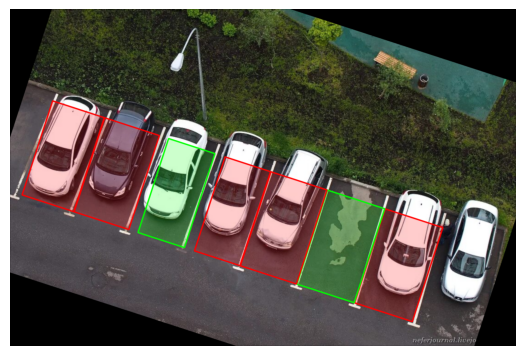

In [7]:
kernel_h1 = cv2.getStructuringElement(cv2.MORPH_RECT, (15, 15))

h1 = hard[0]

h1 = rotate_h1(h1, 18)


blurred_h1 = cv2.GaussianBlur(h1,(3,3),10)
# plot_images_from_sets(blurred_h1)

kernel_h1 = cv2.getStructuringElement(cv2.MORPH_RECT, (15, 15))
shadow_removed_h1 = cv2.morphologyEx(blurred_h1, cv2.MORPH_TOPHAT, kernel_h1)
# plot_images_from_sets(shadow_removed)

gray_shadow_removed_h1 = cv2.cvtColor(shadow_removed_h1, cv2.COLOR_BGR2GRAY)
thresholded_h1 = cv2.threshold(gray_shadow_removed_h1, 0, 255, cv2.THRESH_OTSU)[1]


#dilate the set next
dkernel_h1 = cv2.getStructuringElement(cv2.MORPH_RECT, (1, 10))
dilated_hard_h1 = cv2.dilate(thresholded_h1, dkernel_h1, iterations=1)


#harris corner detection
harris_images_h1, harris_points_hard_h1 = harris_corner_detection_hard(dilated_hard_h1, 0.25, [255, 0, 0])
# plot_images_from_sets([harris_images_h1])


shadow_removed_h1 = cv2.morphologyEx(h1, cv2.MORPH_TOPHAT, kernel)
gray_shadow_removed_h1 = cv2.cvtColor(shadow_removed_h1, cv2.COLOR_BGR2GRAY)
binary_h1 = cv2.threshold(gray_shadow_removed_h1, 50, 255, cv2.THRESH_BINARY)[1]


vertical_kernel_h1 = cv2.getStructuringElement(cv2.MORPH_RECT, (1, 20))
horizontal_kernel_h1 = cv2.getStructuringElement(cv2.MORPH_RECT, (55, 1))

vjoin_kernel_h1 = cv2.getStructuringElement(cv2.MORPH_RECT, (1, 25))
hjoin_kernel_h1 = cv2.getStructuringElement(cv2.MORPH_RECT, (25, 1))

dkernel = cv2.getStructuringElement(cv2.MORPH_RECT, (1, 10))
dilated_h1 = cv2.dilate(binary_h1, dkernel, iterations=1)


vertical_lines_removed_h1 = cv2.morphologyEx(dilated_h1, cv2.MORPH_OPEN,vertical_kernel_h1)
horizontal_lines_removed_h1 = cv2.morphologyEx(binary_h1, cv2.MORPH_OPEN, horizontal_kernel_h1)


joined_hard_h1 = cv2.bitwise_or(vertical_lines_removed_h1, horizontal_lines_removed_h1)




# # Convert to grayscale before finding contours
filtered_ver_h1, lines_h1 = filter_lines_h1(vertical_lines_removed_h1, length_threshold=450, width_threshold=25, gap_threshold=False)
filtered_hor_h1 = filter_lines_h1(horizontal_lines_removed_h1, length_threshold=300, width_threshold=100000)[0]



joined_h1 = cv2.bitwise_or(filtered_ver_h1, filtered_hor_h1)



copy_joined_hard = joined_h1.copy()

for pset in harris_points_hard_h1:
    for point in pset:
        if np.all(joined_h1[point[1], point[0]] == 255):
            cv2.circle(joined_h1, point, 6, (255, 0, 0), -1)

boxes_h1 = completing_boxes_h1(joined_h1,copy_joined_hard, 2)
# plot_images_from_sets([boxes_h1])


boxed_images_set1, parking_spaces_h1 = find_parking_spaces_h1(boxes_h1, 0.5)

# plot_images_from_sets([boxed_images_set1])


final_h1 = h1.copy()


for (x, y, w, h) in parking_spaces_h1:
    box = False
    corner_count = 0
    for set in harris_points_hard_h1:
        for px, py in set:
            if x + w * 0.25 <= px <= x + w * 0.75 and y + h * 0.25 <= py <= y + h * 0.75:
                corner_count += 1
                if corner_count > 15:
                    box = True
                    break
    color = (255, 0, 0) if box else (0, 255, 0)
    cv2.rectangle(final_h1, (x, y), (x + w, y + h), color, 2)
    overlay = final_h1.copy()
    cv2.rectangle(overlay, (x, y), (x + w, y + h), color, -1)
    cv2.addWeighted(overlay, 0.2, final_h1, 0.8, 0, final_h1)

    
final_h1 = rotate_h1(final_h1, -18)

plot_images_from_sets([final_h1])




### Image 2

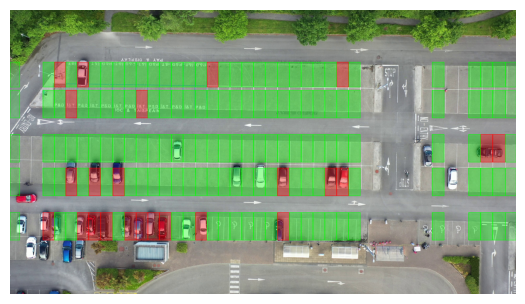

In [8]:
#blue masking 


h2 = hard[1]
cm = blue_and_white_colour_masking(hard[1])



grey_h2 = cv2.cvtColor(cm, cv2.COLOR_RGB2GRAY)
thresholded_h2 = cv2.threshold(grey_h2, 0, 255, cv2.THRESH_OTSU)[1]


vertical_kernel_h2 = cv2.getStructuringElement(cv2.MORPH_RECT, (1, 95))
horizontal_kernel_h2 = cv2.getStructuringElement(cv2.MORPH_RECT, (100, 1))
vertical_lines_removed_h2 = cv2.morphologyEx(thresholded_h2, cv2.MORPH_OPEN, vertical_kernel_h2)
horizontal_lines_removed_h2 = cv2.morphologyEx(thresholded_h2, cv2.MORPH_OPEN, horizontal_kernel_h2)


dkernel_v_h2 = cv2.getStructuringElement(cv2.MORPH_RECT, (1, 10))
dilated_h2 = cv2.dilate(vertical_lines_removed_h2, dkernel_v_h2, iterations=1)
filtered_ver_h2, lines_h2 = filter_lines_h2(dilated_h2, length_threshold=350, width_threshold=15, gap_threshold=True)

dkernel_h_h2 = cv2.getStructuringElement(cv2.MORPH_RECT, (10, 1))
dilated_h2 = cv2.dilate(vertical_lines_removed_h2, dkernel_h_h2, iterations=5)
filtered_hor_h2 = filter_lines_h2(horizontal_lines_removed_h2, length_threshold=550, width_threshold=100000)[0]


final_h2 = cv2.bitwise_or(filtered_ver_h2, filtered_hor_h2)

copy_joined_h2 = final_h2.copy() 


blurred_h2 = cv2.GaussianBlur(h2,(5,5),10)
# plot_images_from_sets(blurred)

kernel_h2 = cv2.getStructuringElement(cv2.MORPH_RECT, (15, 15))
shadow_removed_h2 = cv2.morphologyEx(blurred_h2, cv2.MORPH_TOPHAT, kernel_h2)
# plot_images_from_sets(shadow_removed)

gray_shadow_removed_h2 = cv2.cvtColor(shadow_removed_h2, cv2.COLOR_BGR2GRAY)
thresholded_h2 = cv2.threshold(gray_shadow_removed_h2, 0, 255, cv2.THRESH_OTSU)[1]
# plot_images_from_sets(thresholded)



#harris corner detection
harris_image_h2, harris_points_h2 = harris_corner_detection_hard(thresholded_h2, 0.4, [255, 0, 0])




finals_h2 = []
filt_points_h2 = []
one_set_h2 = []


for point in harris_points_h2[0]:
    if np.all(final_h2[point[1], point[0]] == 255):
        one_set_h2.extend(point)
        cv2.circle(final_h2, point, 6, (255, 0, 0), -1)



    
img_h2 = completing_boxes_h2(final_h2,copy_joined_h2, 15)





# Example usage:
bbox_h2, ps_h2 = find_parking_spaces_h2(img_h2, 80, at=500, e=False, max_height=210)


final_h2 = h2.copy()

if isinstance(ps_h2, list):
    for (x, y, w, h) in ps_h2:
        box = False
        corner_count = 0
        for points in harris_points_h2:
            for px, py in points:
                if x + w * 0.2 <= px <= x + w * 0.8 and y + h * 0.2 <= py <= y + h * 0.8:
                    corner_count += 1
                    if corner_count > 11:
                        box = True
                        break
               
        color = (255, 0, 0) if box else (0, 255, 0)
        cv2.rectangle(final_h2, (x, y), (x + w, y + h), color, 2)
        overlay_h2 = final_h2.copy()
        cv2.rectangle(overlay_h2, (x, y), (x + w, y + h), color, -1)
        cv2.addWeighted(overlay_h2, 0.2, final_h2, 0.8, 0, final_h2)

    

plot_images_from_sets([final_h2])




### Image 3

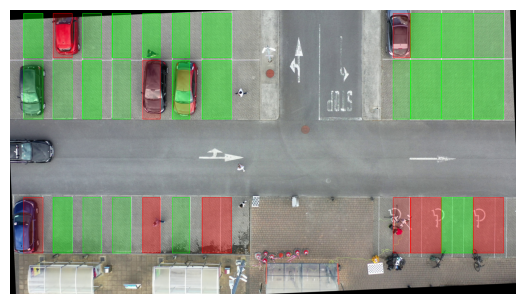

In [9]:


rh3 = rotate_h3(hard[2])



blurred = cv2.GaussianBlur(rh3,(5,5),10)
# plot_images_from_sets(blurred)

kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (15, 15))
shadow_removed = cv2.morphologyEx(blurred, cv2.MORPH_TOPHAT, kernel)
# plot_images_from_sets(shadow_removed)

gray_shadow_removed = cv2.cvtColor(shadow_removed, cv2.COLOR_BGR2GRAY)
thresholded = cv2.threshold(gray_shadow_removed, 75, 255, cv2.THRESH_BINARY)[1]
# plot_images_from_sets(thresholded)

#dilate the set next
dkernel = cv2.getStructuringElement(cv2.MORPH_RECT, (1, 10))
dilated = cv2.dilate(thresholded, dkernel, iterations=1)
# plot_images_from_sets(dilated)


#harris corner detection
harris_image, harris_points_h3 = harris_corner_detection_hard(dilated, 0.05, [255, 0, 0])


vertical_kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (1, 25))
horizontal_kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (100, 1))
vertical_lines_removed = cv2.morphologyEx(thresholded, cv2.MORPH_OPEN, vertical_kernel)
horizontal_lines_removed = cv2.morphologyEx(thresholded, cv2.MORPH_OPEN, horizontal_kernel)




dkernel_v = cv2.getStructuringElement(cv2.MORPH_RECT, (1, 15))
dilated = cv2.dilate(vertical_lines_removed, dkernel_v, iterations=1)
filtered_ver, lines = filter_lines_h3(dilated, length_threshold=200, width_threshold=6, gap_threshold= False)




dkernel_h = cv2.getStructuringElement(cv2.MORPH_RECT, (25, 1))
dilated = cv2.dilate(vertical_lines_removed, dkernel_h, iterations=5)
filtered_hor = filter_lines(horizontal_lines_removed, length_threshold=550, width_threshold=100000)[0]



merged = cv2.bitwise_or(filtered_ver, filtered_hor)
copy_joined_h3 = merged.copy()


finals_h3 = []
filt_points = []
one_set = []


for point in harris_points_h3[0]:
    if np.all(merged[point[1], point[0]] == 255):
        one_set.extend(point)
        cv2.circle(merged, point, 6, (255, 0, 0), -1)


    
img = completing_boxes_h3(merged,copy_joined_h3, 5)

bbox_h3, ps_h3 = find_parking_spaces_h3(img, 190, at= 60000000000000, e=False)



final_h3 = rh3.copy()

if isinstance(ps_h3, list):
    for (x, y, w, h) in ps_h3:
        box = False
        corner_count = 0
        for points in harris_points_h3:
            for px, py in points:
                if x + w * 0.2 <= px <= x + w * 0.8 and y + h * 0.2 <= py <= y + h * 0.8:
                    corner_count += 1
                    if corner_count > 5:
                        box = True
                        break
               
        color = (255, 0, 0) if box else (0, 255, 0)
        cv2.rectangle(final_h3, (x, y), (x + w, y + h), color, 2)
        overlay = final_h3.copy()
        cv2.rectangle(overlay, (x, y), (x + w, y + h), color, -1)
        cv2.addWeighted(overlay, 0.2, final_h3, 0.8, 0, final_h3)



plot_images_from_sets([final_h3])

